# IMPORTS

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from diive.core.io.files import save_parquet, load_parquet
from diive.core.times.times import TimestampSanitizer

# LOAD DATA

## Partitioning results

In [2]:
part_path = "81.5.1_NEE_XG-GAPF_PART_ReddyProc.csv"
part_df = pd.read_csv(part_path)
part_df = part_df.set_index("TIMESTAMP")
part_df.index.name = "TIMESTAMP_END"
part_df = TimestampSanitizer(data=part_df).get()
part_df

,Tair_orig,Tair_f,Tair_fqc,Tair_fall,Tair_fall_qc,Tair_fnum,Tair_fsd,Tair_fmeth,Tair_fwin,Rg_orig,Rg_f,Rg_fqc,Rg_fall,Rg_fall_qc,Rg_fnum,...,FP_GPP2000,FP_k,FP_beta,FP_alpha,FP_RRef,FP_E0,FP_k_sd,FP_beta_sd,FP_alpha_sd,FP_RRef_sd,FP_E0_sd,Reco_DT_QCF0,GPP_DT_QCF0,Reco_DT_QCF0_SD,GPP_DT_QCF0_SD
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-06 23:15:00,7.366667,7.366667,0,7.366667,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.204353,0.000000,0.090858,0.000000
2023-11-06 23:45:00,7.333333,7.333333,0,7.333333,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.202919,0.000000,0.090793,0.000000
2023-11-07 00:15:00,7.000000,7.000000,0,7.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.188529,0.000000,0.090168,0.000000
2023-11-07 00:45:00,6.566667,6.566667,0,6.566667,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.169693,0.000000,0.089430,0.000000
2023-11-07 01:15:00,5.433333,5.433333,0,5.433333,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.119732,0.000000,0.087903,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 19:45:00,16.290000,16.290000,0,16.290000,NaN,NaN,NaN,NaN,NaN,26.336951,26.336951,0,26.336951,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.922076,3.601595,0.333993,0.178586
2025-06-04 20:15:00,16.073333,16.073333,0,16.073333,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.838305,0.000000,0.333351,0.000000
2025-06-04 20:45:00,15.886667,15.886667,0,15.886667,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.766235,0.000000,0.334085,0.000000


## Gap-filling results

In [4]:
gapfilled_df = load_parquet(Path("81.4.1_NEE_GF-XGBoost.parquet"))
gapfilled_df

Loaded .parquet file 81.4.1_NEE_GF-XGBoost.parquet (0.576 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,NEE_L3.3_CUT_50_QCF_gfXGBoost,FLAG_NEE_L3.3_CUT_50_QCF_gfXGBoost_ISFILLED,NEE_L3.3_CUT_50_QCF0_gfXGBoost,FLAG_NEE_L3.3_CUT_50_QCF0_gfXGBoost_ISFILLED
TIMESTAMP_MIDDLE,,,,
2023-11-08 00:15:00,2.367268,1,2.367268,1
2023-11-08 00:45:00,2.238080,1,2.238080,1
2023-11-08 01:15:00,2.207177,1,2.207177,1
2023-11-08 01:45:00,2.186978,1,2.186978,1
2023-11-08 02:15:00,2.179536,1,2.179536,1
...,...,...,...,...
2025-06-05 21:45:00,7.543205,1,7.543205,1
2025-06-05 22:15:00,7.461149,1,7.461149,1
2025-06-05 22:45:00,7.744204,1,7.744204,1


# CLEAN PARTITIONING RESULTS

## Identify GPP and RECO columns

In [5]:
partcols = [c for c in part_df.columns if any(substring in c for substring in ["GPP", "Reco"])];
partcols = [c for c in partcols if not str(c).endswith("_fqc") and not str(c).endswith("_SD") and '_DT' not in c] 
partcols.remove("FP_GPP2000")
partcols

['Reco_QCF', 'GPP_QCF_f', 'Reco_QCF0', 'GPP_QCF0_f']

## Create subset with GPP and RECO columns

In [6]:
subset_partcols = part_df[partcols].copy()
subset_partcols

,Reco_QCF,GPP_QCF_f,Reco_QCF0,GPP_QCF0_f
TIMESTAMP_MIDDLE,,,,
2023-11-06 23:15:00,1.640426,0.075071,1.640426,0.075071
2023-11-06 23:45:00,1.639266,0.075964,1.639266,0.075964
2023-11-07 00:15:00,1.627627,0.088274,1.627627,0.088274
2023-11-07 00:45:00,1.612401,0.077929,1.612401,0.077929
2023-11-07 01:15:00,1.572075,0.024026,1.572075,0.024026
...,...,...,...,...
2025-06-04 19:45:00,8.892019,1.749723,8.892019,1.749723
2025-06-04 20:15:00,8.861958,-0.846220,8.861958,-0.846220
2025-06-04 20:45:00,8.835974,-1.332143,8.835974,-1.332143


## Rename partitioning variables

In [7]:
renaming_dict = {
    # Nighttime paritioning results for parcels A and B
    'GPP_QCF_f': 'GPP_NT_CUT_50_gfXG_QCF',
    'GPP_QCF0_f': 'GPP_NT_CUT_50_gfXG_QCF0',
    'Reco_QCF': 'RECO_NT_CUT_50_gfXG_QCF',
    'Reco_QCF0': 'RECO_NT_CUT_50_gfXG_QCF0'
}

subset_partcols = subset_partcols.rename(columns=renaming_dict, inplace=False)
subset_partcols

,RECO_NT_CUT_50_gfXG_QCF,GPP_NT_CUT_50_gfXG_QCF,RECO_NT_CUT_50_gfXG_QCF0,GPP_NT_CUT_50_gfXG_QCF0
TIMESTAMP_MIDDLE,,,,
2023-11-06 23:15:00,1.640426,0.075071,1.640426,0.075071
2023-11-06 23:45:00,1.639266,0.075964,1.639266,0.075964
2023-11-07 00:15:00,1.627627,0.088274,1.627627,0.088274
2023-11-07 00:45:00,1.612401,0.077929,1.612401,0.077929
2023-11-07 01:15:00,1.572075,0.024026,1.572075,0.024026
...,...,...,...,...
2025-06-04 19:45:00,8.892019,1.749723,8.892019,1.749723
2025-06-04 20:15:00,8.861958,-0.846220,8.861958,-0.846220
2025-06-04 20:45:00,8.835974,-1.332143,8.835974,-1.332143


# MERGE

In [8]:
df = pd.concat([gapfilled_df, subset_partcols], axis=1)
df

,NEE_L3.3_CUT_50_QCF_gfXGBoost,FLAG_NEE_L3.3_CUT_50_QCF_gfXGBoost_ISFILLED,NEE_L3.3_CUT_50_QCF0_gfXGBoost,FLAG_NEE_L3.3_CUT_50_QCF0_gfXGBoost_ISFILLED,RECO_NT_CUT_50_gfXG_QCF,GPP_NT_CUT_50_gfXG_QCF,RECO_NT_CUT_50_gfXG_QCF0,GPP_NT_CUT_50_gfXG_QCF0
TIMESTAMP_MIDDLE,,,,,,,,
2023-11-06 23:15:00,NaN,<NA>,NaN,<NA>,1.640426,0.075071,1.640426,0.075071
2023-11-06 23:45:00,NaN,<NA>,NaN,<NA>,1.639266,0.075964,1.639266,0.075964
2023-11-07 00:15:00,NaN,<NA>,NaN,<NA>,1.627627,0.088274,1.627627,0.088274
2023-11-07 00:45:00,NaN,<NA>,NaN,<NA>,1.612401,0.077929,1.612401,0.077929
2023-11-07 01:15:00,NaN,<NA>,NaN,<NA>,1.572075,0.024026,1.572075,0.024026
...,...,...,...,...,...,...,...,...
2025-06-05 21:45:00,7.543205,1,7.543205,1,NaN,NaN,NaN,NaN
2025-06-05 22:15:00,7.461149,1,7.461149,1,NaN,NaN,NaN,NaN
2025-06-05 22:45:00,7.744204,1,7.744204,1,NaN,NaN,NaN,NaN


# PLOT

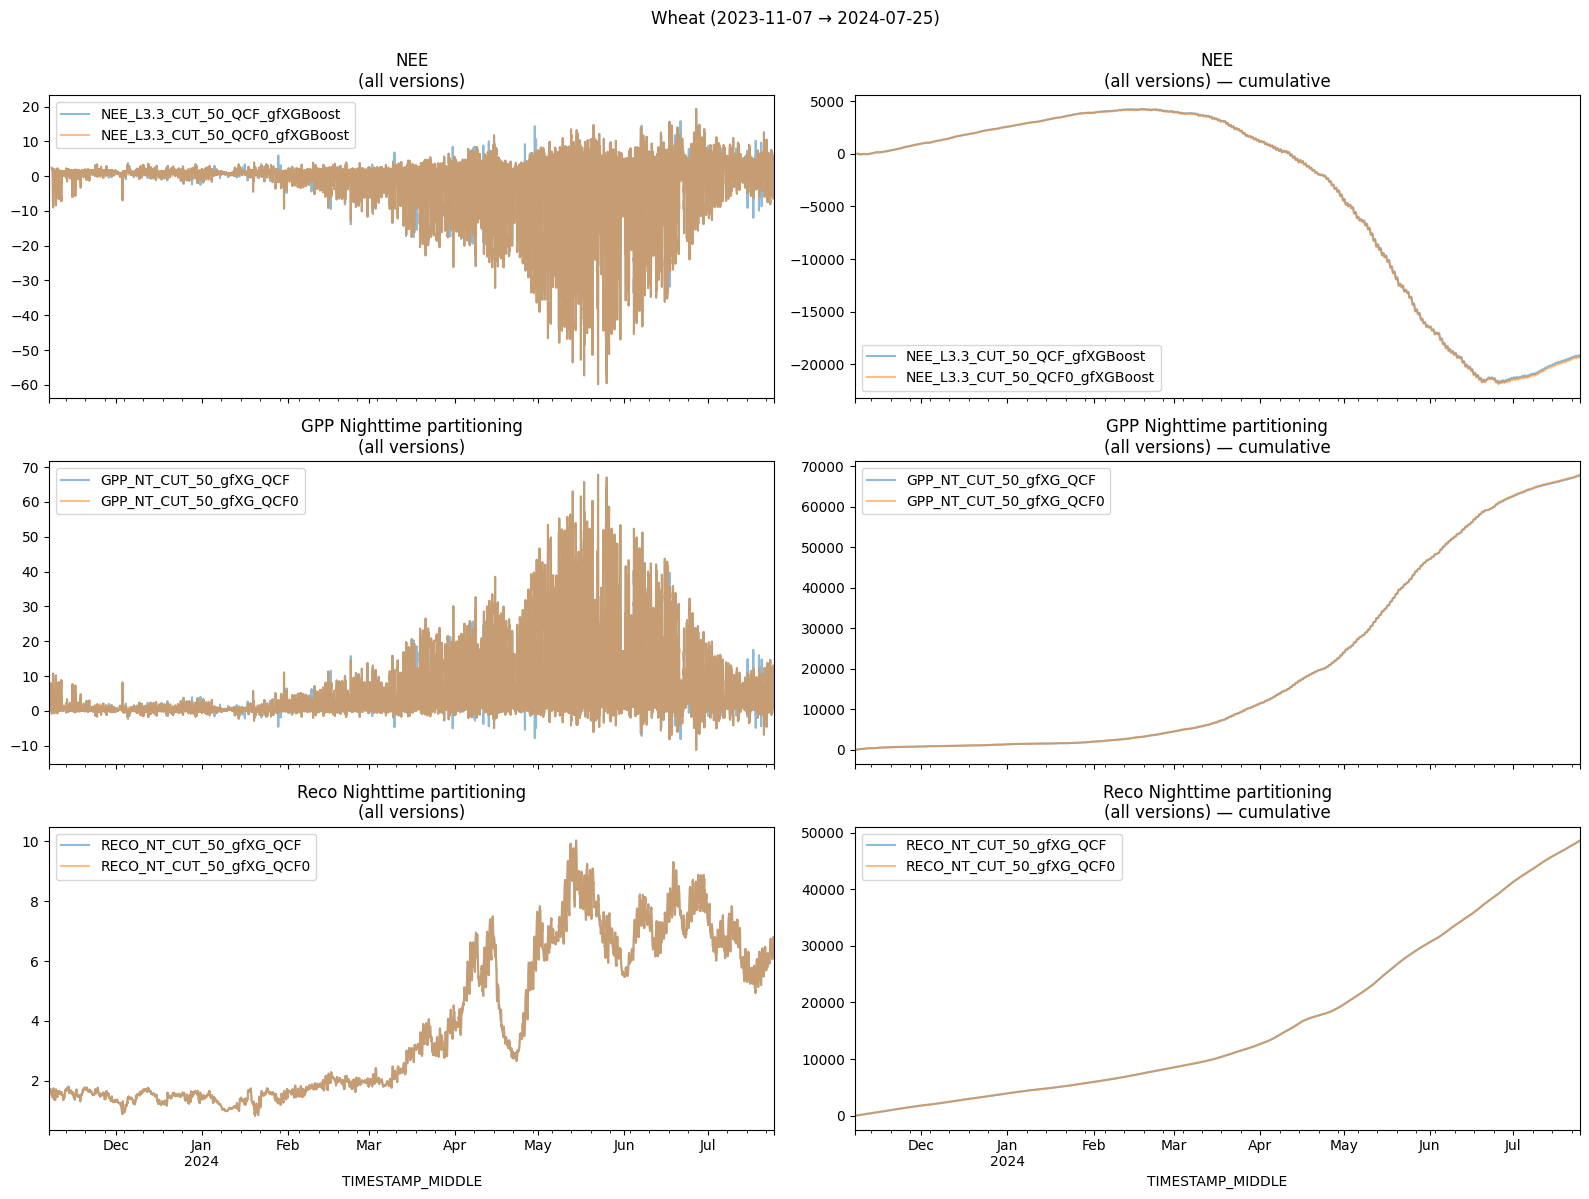

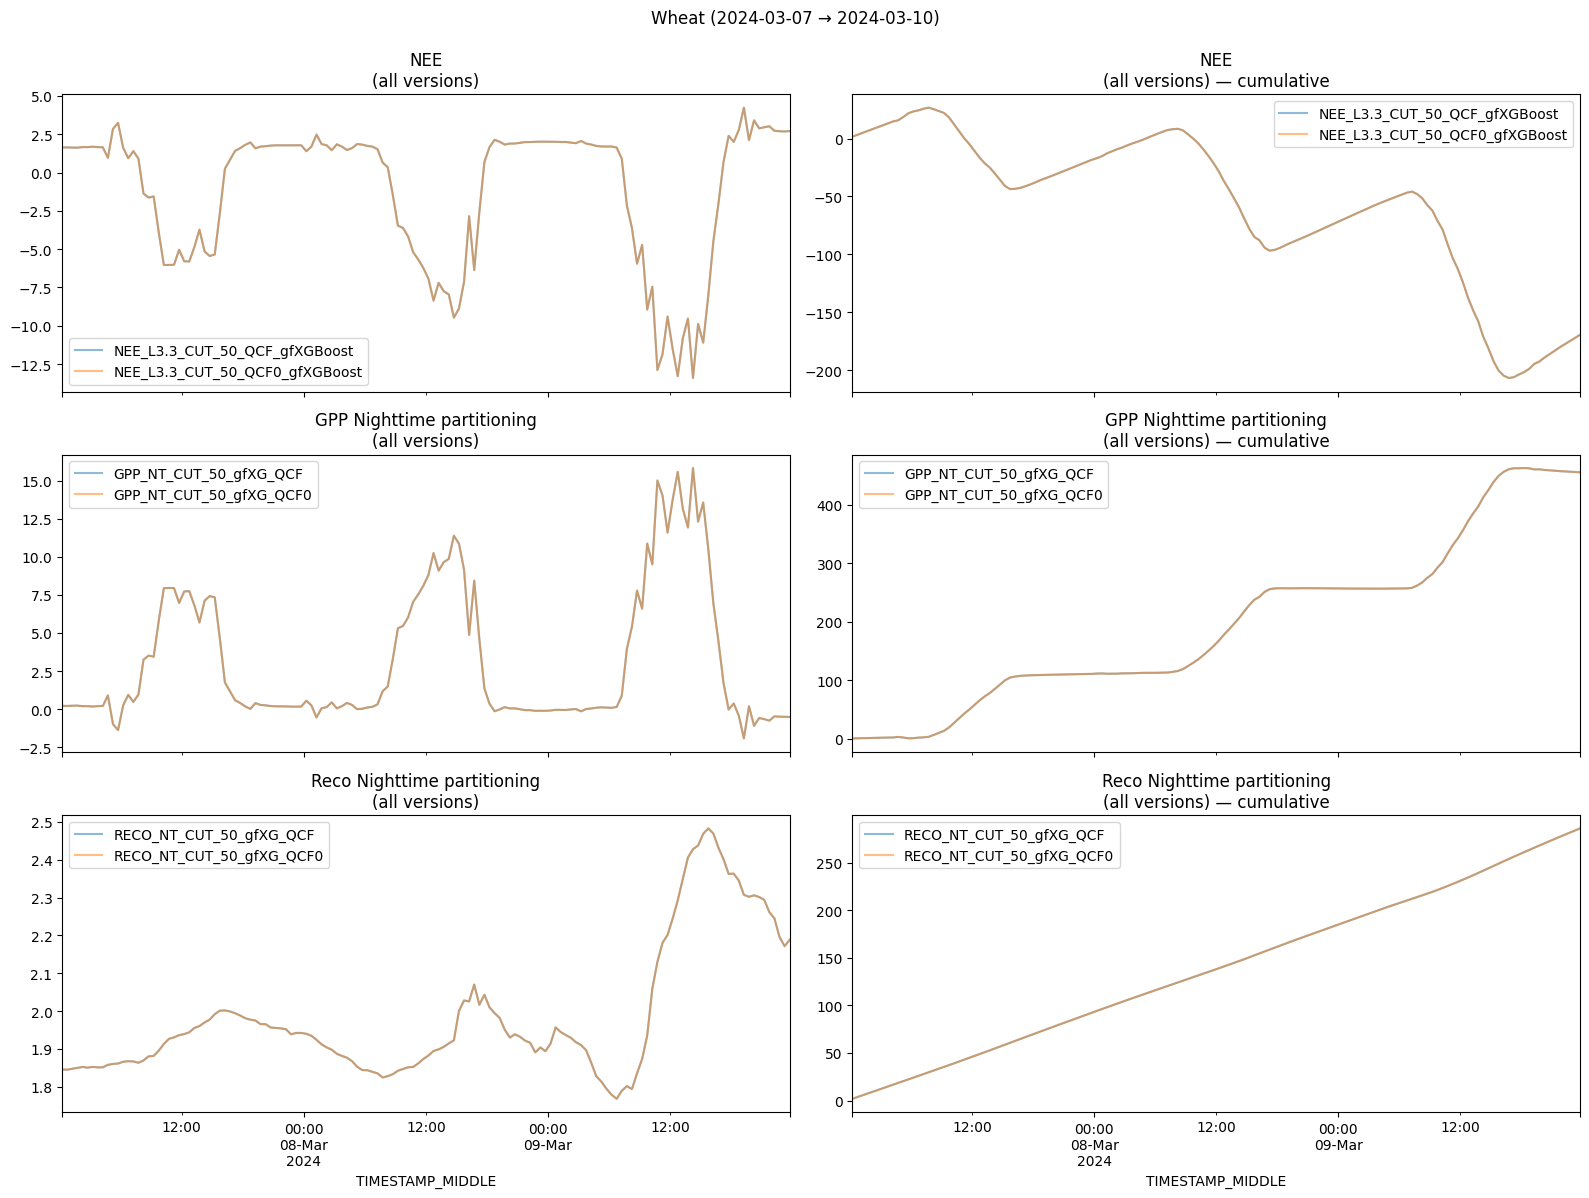

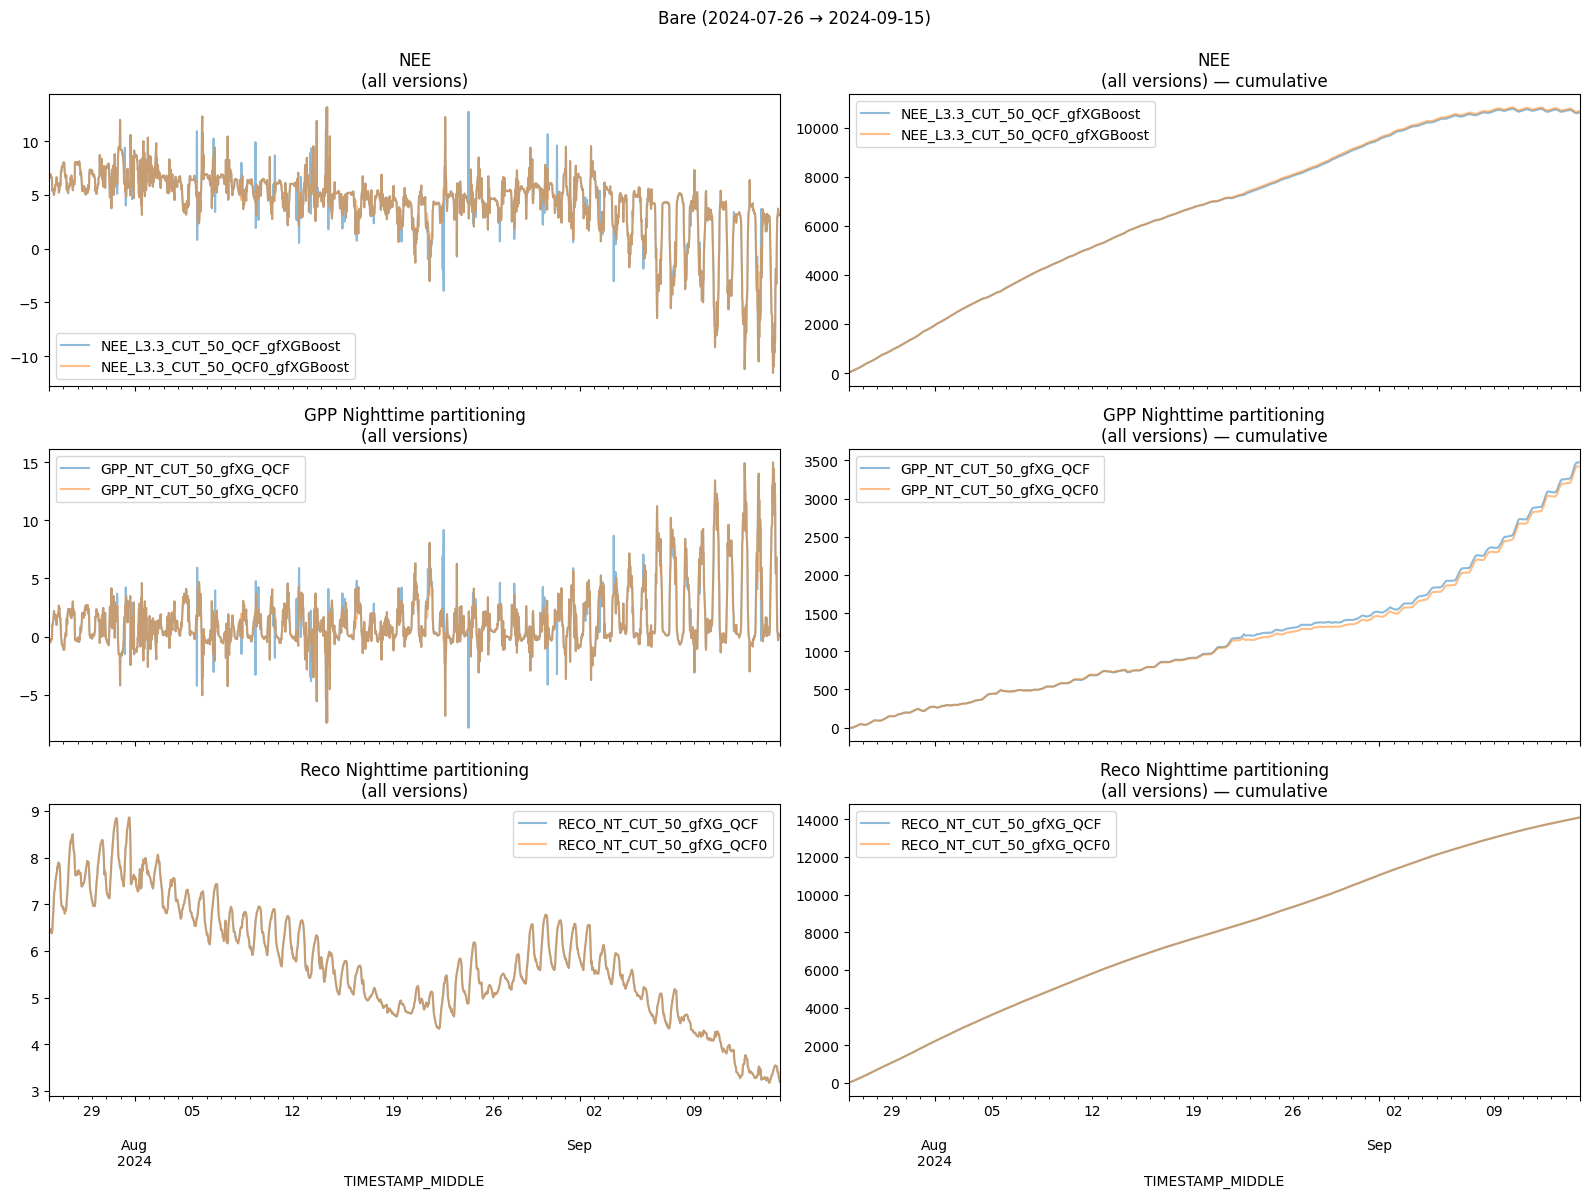

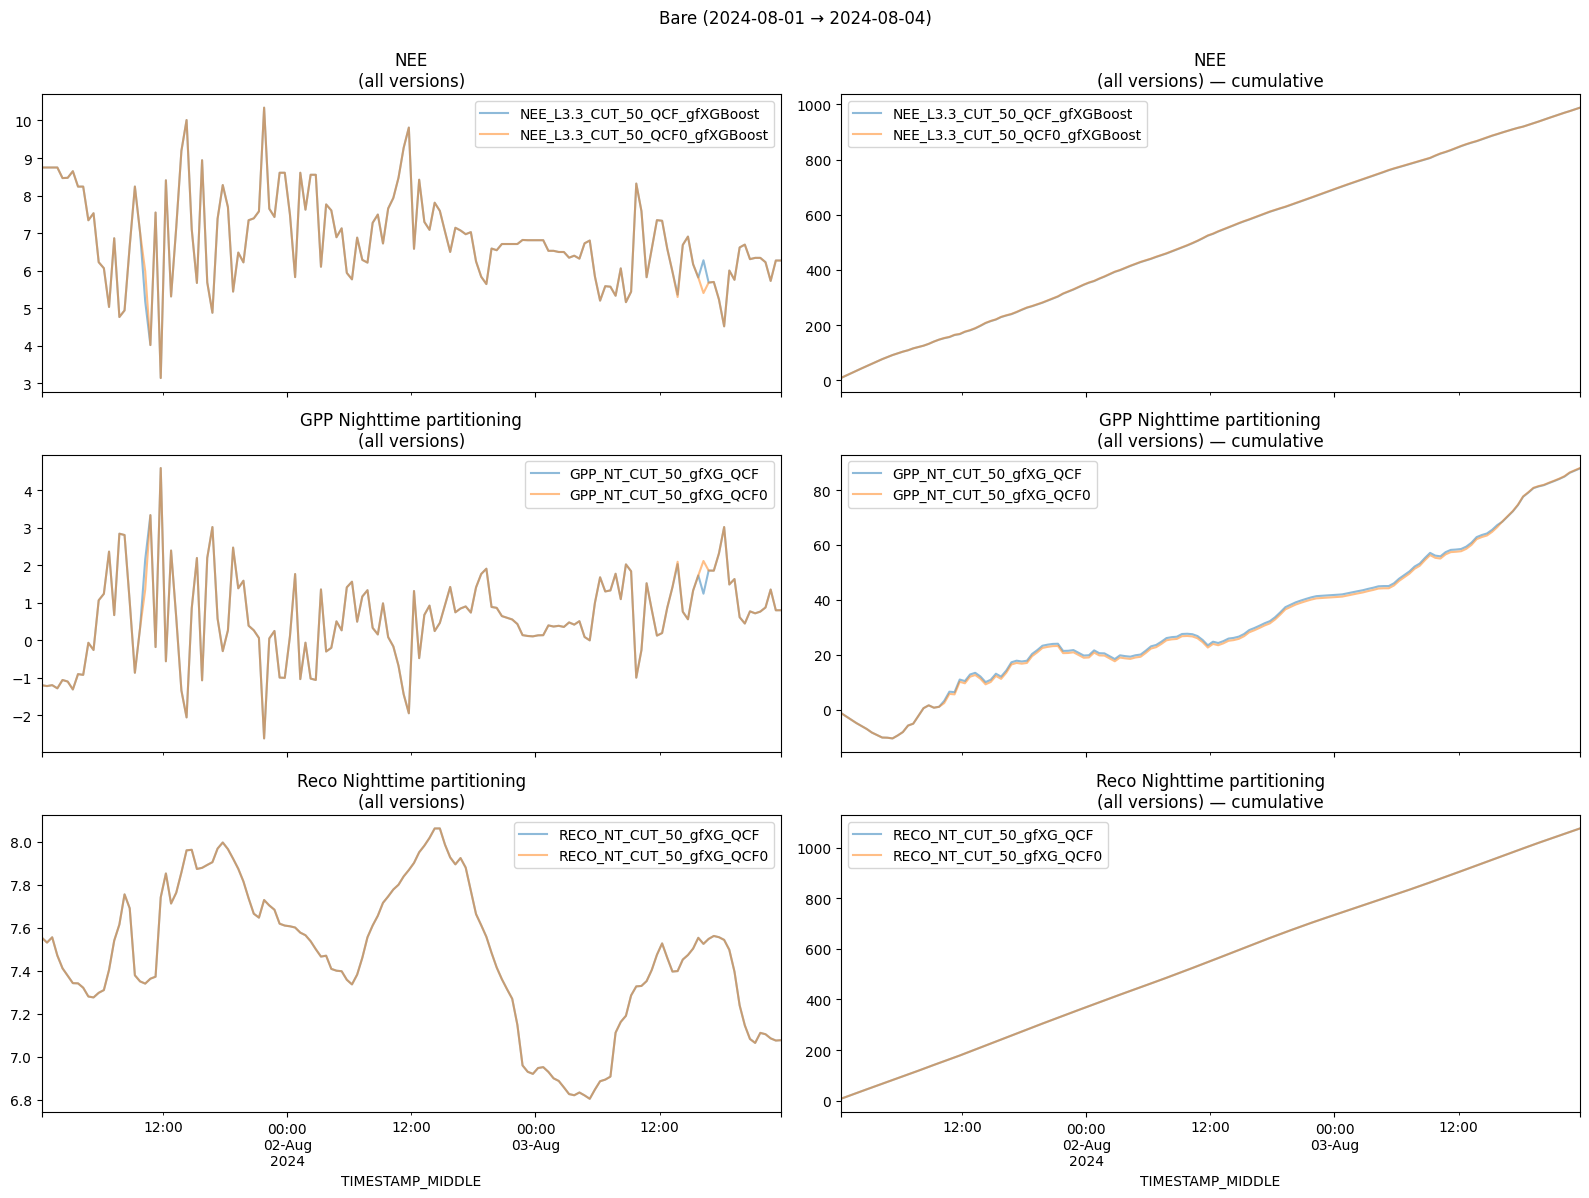

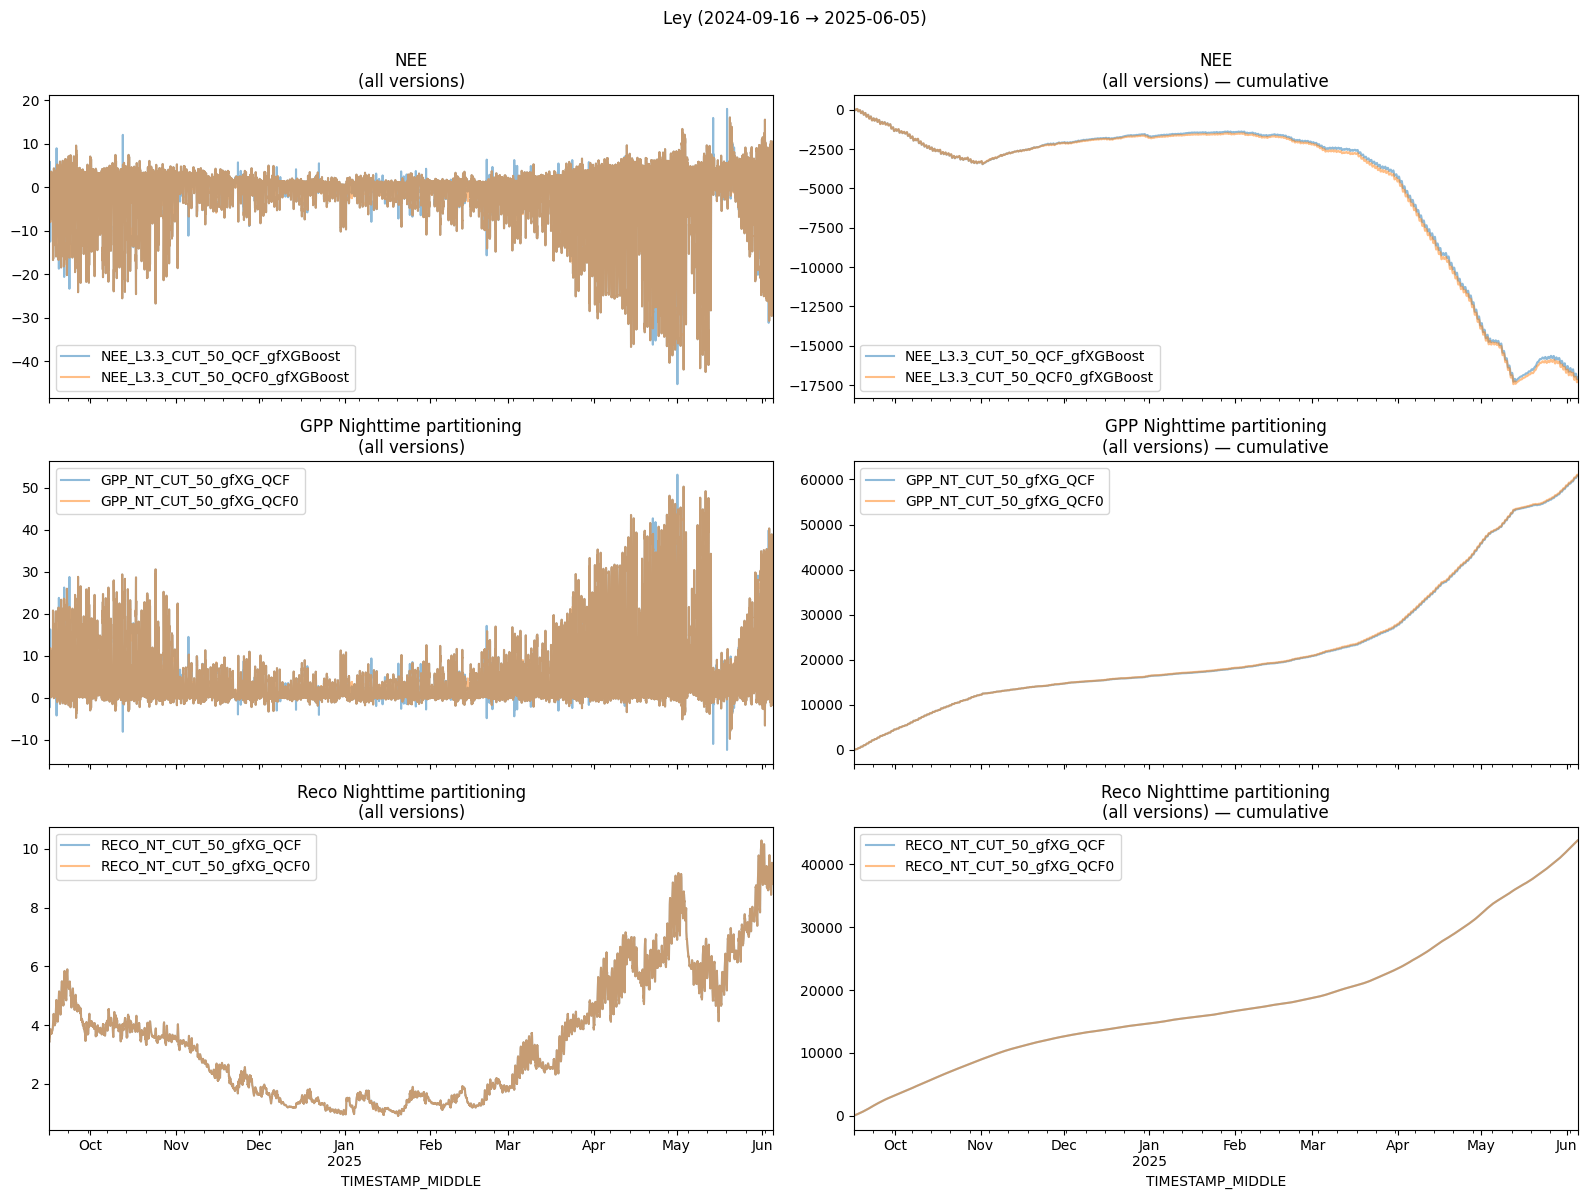

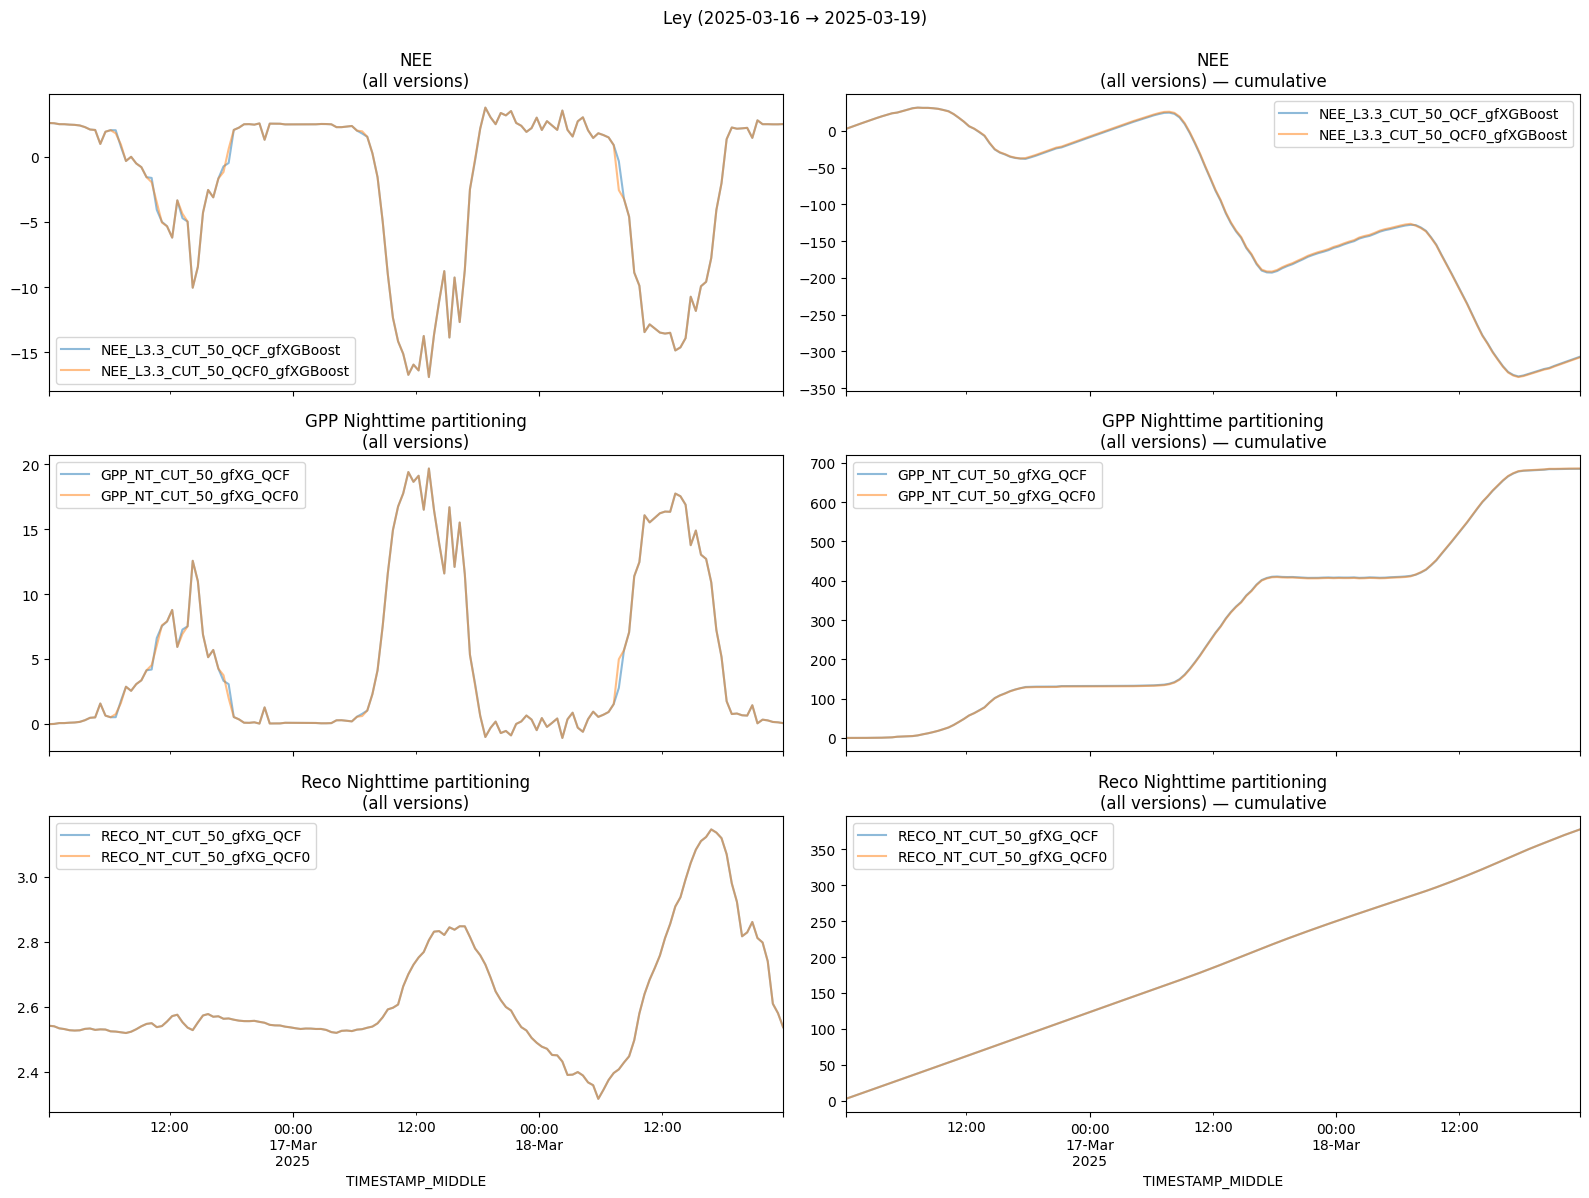

In [15]:
# Define periods
periods = [
    ("2023-11-07", "2024-07-25", "Wheat"),
    ("2024-03-07", "2024-03-10", "Wheat"),
    ("2024-07-26", "2024-09-15", "Bare"),
    ("2024-08-01", "2024-08-04", "Bare"),
    ("2024-09-16", "2025-06-05", "Ley"),
    ("2025-03-16", "2025-03-19", "Ley")
]


for start, end, label in periods:
    period_df = df.loc[pd.to_datetime(start):pd.to_datetime(end)]
    pairs = [
        ([c for c in df.columns if c.startswith('NEE')], "NEE\n(all versions)"),       
        ([c for c in df.columns if c.startswith('GPP_NT')], "GPP Nighttime partitioning\n(all versions)"),
        ([c for c in df.columns if c.startswith('RECO_NT')], "Reco Nighttime partitioning\n(all versions)"),
    ]

    # Keep only existing columns
    pairs = [(cols, t) for cols, t in pairs if all(c in period_df.columns for c in cols)]
    nrows, ncols = len(pairs), 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows), sharex='col')
    if nrows == 1:  # make indexing uniform
        axes = axes.reshape(1, ncols)

    for r, (cols, t) in enumerate(pairs):
        # raw
        period_df[cols].plot(ax=axes[r, 0], alpha=0.5)
        axes[r, 0].set_title(f"{t}")

        # cumulative
        cumulative = period_df[cols].cumsum()
        cumulative.plot(ax=axes[r, 1], alpha=0.5)
        axes[r, 1].set_title(f"{t} — cumulative")

    fig.suptitle(f"{label} ({start} → {end})", y=0.995, fontsize=12)
    plt.tight_layout()
    plt.show()

# EXPORT DATA

In [16]:
filename = "81.6.1_NEE_GF-XGBoost_GPP_RECO"
save_parquet(data=df, filename=filename)

Saved file 81.6.1_NEE_GF-XGBoost_GPP_RECO.parquet (0.205 seconds).


'81.6.1_NEE_GF-XGBoost_GPP_RECO.parquet'

# End of notebook

In [17]:
from datetime import datetime
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-12-11 13:36:12
